In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
customers=pd.read_csv(r"C:\Users\Pravalika.b\OneDrive\Documents\olist_customers_dataset.csv",)
orders=pd.read_csv(r"C:\Users\Pravalika.b\OneDrive\Documents\olist_orders_dataset.csv")
order_items=pd.read_csv(r"C:\Users\Pravalika.b\OneDrive\Documents\olist_order_items_dataset.csv")
payments=pd.read_csv(r"C:\Users\Pravalika.b\OneDrive\Documents\olist_order_payments_dataset.csv")

In [7]:
print("Customers:", customers.shape)
print("orders:",orders.shape)
print("order items:",order_items.shape)
print("payments:",payments.shape)

Customers: (99441, 5)
orders: (99441, 8)
order items: (112650, 7)
payments: (103886, 5)


In [9]:
print("\n customers columns:")
print(customers.columns.tolist())
print("\n orders columns:")
print(orders.columns.tolist())
print("\n orders items columns:")
print(order_items.columns.tolist())
print("\n payments columns:")
print(payments.columns.tolist())


 customers columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

 orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

 orders items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

 payments columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


In [11]:
orders["order_purchase_timestamp"]=pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [12]:
delivered_orders=orders[
    orders["order_status"]=="delivered"
].copy()
print("\n delivered orders:",len(delivered_orders))


 delivered orders: 96478


In [14]:
## Connect orders with customer unique ID
customer_order=delivered_orders.merge(
    customers[
        ["customer_id","customer_unique_id"]
    ],
    on="customer_id",
    how="left"
)
print("\n Customer order table:")
print(customer_order.head())


 Customer order table:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp order_approved_at  \
0    delivered      2017-10-02 10:56:00   10/2/2017 11:07   
1    delivered      2018-07-24 20:41:00    7/26/2018 3:24   
2    delivered      2018-08-08 08:38:00     8/8/2018 8:55   
3    delivered      2017-11-18 19:28:00  11/18/2017 19:45   
4    delivered      2018-02-13 21:18:00   2/13/2018 22:20   

  order_delivered_carrier_date order_delivered_customer_date  \
0              10/4/2017 19:55              10/10/2017 21:25   
1              7/26/2018 14:31            

In [15]:
## count orders for each customer
customer_order_count=(
    customer_order
    .groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index()
)
customer_order_count.rename(
    columns={"order_id":"total_orders"},
    inplace=True
)
print("\n customer order count:")
print(customer_order_count.head())


 customer order count:
                 customer_unique_id  total_orders
0  0000366f3b9a7992bf8c76cfdf3221e2             1
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1
2  0000f46a3911fa3c0805444483337064             1
3  0000f6ccb0745a6a4b88665a16c9f078             1
4  0004aac84e0df4da2b147fca70cf8255             1


In [17]:
## create customer segment 
def customer_segment(order_count):
    if order_count==1:
        return "One-Time"
    elif order_count<=3:
        return "Repeat"
    elif order_count <-5:
        return "Loyal"
    else:
        return "Highly Loyal"
customer_order_count["segment"]=(
    customer_order_count["total_orders"]
    .apply(customer_segment)
)
print("\n customer segments:")
print(customer_order_count.head())


 customer segments:
                 customer_unique_id  total_orders   segment
0  0000366f3b9a7992bf8c76cfdf3221e2             1  One-Time
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1  One-Time
2  0000f46a3911fa3c0805444483337064             1  One-Time
3  0000f6ccb0745a6a4b88665a16c9f078             1  One-Time
4  0004aac84e0df4da2b147fca70cf8255             1  One-Time


In [19]:
## repeat purchase rate
total_customers=len(customer_order_count)
repeat_customers=(
    customer_order_count["total_orders"]>=2
).sum()
one_time_customers=(
    customer_order_count["total_orders"]==1
).sum()
repeat_rate=(
    repeat_customers/total_customers
)*100
print("REPEAT PURCHASE ANALYSIS")
print("Total customers:",total_customers)
print("one-time customers:",one_time_customers)
print("repeat customers:",repeat_customers)
print("repeat purchase rate:",round(repeat_rate,2),"%")

REPEAT PURCHASE ANALYSIS
Total customers: 93358
one-time customers: 90557
repeat customers: 2801
repeat purchase rate: 3.0 %


In [20]:
## create order revenue
order_item_revenue=(
    order_items
    .groupby("order_id")["price"]
    .sum()
    .reset_index()
)
order_item_revenue.rename(
    columns={"price":"order_revenue"},
    inplace=True
)


In [21]:
## add revenue to customer orders
customer_order_revenue=customer_order.merge(
    order_item_revenue,
    on="order_id",
    how="left"
)
customer_order_revenue["order_revenue"]=(
    customer_order_revenue["order_revenue"]
    .fillna(0)
)

In [22]:
## add customer order count
customer_order_revenue=customer_order_revenue.merge(
    customer_order_count[
        ["customer_unique_id","total_orders","segment"]
    ],
    on="customer_unique_id",
    how="left"
)

In [23]:
## first time vs repeat customers
customer_order_revenue["customer_type"]=np.where(
    customer_order_revenue["total_orders"]==1,
    "First-Time",
    "Repeat"
)
print("\n customer type:")
print(
    customer_order_revenue[
        ["customer_unique_id","total_orders","segment","customer_type"]
    ].head()
)


 customer type:
                 customer_unique_id  total_orders   segment customer_type
0  7c396fd4830fd04220f754e42b4e5bff             2    Repeat        Repeat
1  af07308b275d755c9edb36a90c618231             1  One-Time    First-Time
2  3a653a41f6f9fc3d2a113cf8398680e8             1  One-Time    First-Time
3  7c142cf63193a1473d2e66489a9ae977             1  One-Time    First-Time
4  72632f0f9dd73dfee390c9b22eb56dd6             1  One-Time    First-Time


In [29]:
## first time vs repeat aov
aov_summary=(
    customer_order_revenue
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id","nunique"),
        orders=("order_id","nunique"),
        revenue=("order_revenue","sum")
    )
    .reset_index()
)
aov_summary["AOV"]=(
    aov_summary["revenue"] /
    aov_summary["orders"]
)
print("FIRST-TIME VS REPEAT AOV")
print(aov_summary)

FIRST-TIME VS REPEAT AOV
  customer_type  customers  orders      revenue         AOV
0    First-Time      90557   90557  12493089.36  137.958295
1        Repeat       2801    5921    728408.75  123.021238


In [31]:
## segment summary table
segment_summary=(
    customer_order_revenue
    .groupby("segment")
    .agg(
        customer=("customer_unique_id","nunique"),
        orders=("order_id","nunique"),
        revenue=("order_revenue","sum")
    )
    .reset_index()
    )
segment_summary["AOV"]=(
    segment_summary["revenue"]/
    segment_summary["orders"]
)
segment_summary["customer_percentage"]=(
    segment_summary["customer"]/
    total_customers
)*100
segment_summary["revenue_percentage"]=(
    segment_summary["revenue"]/
    segment_summary["revenue"].sum()
)*100
print("CUSTOMER SEGMENT SUMMARY")
print(segment_summary)

CUSTOMER SEGMENT SUMMARY
        segment  customer  orders      revenue         AOV  \
0  Highly Loyal        47     232     31159.43  134.307888   
1      One-Time     90557   90557  12493089.36  137.958295   
2        Repeat      2754    5689    697249.32  122.560963   

   customer_percentage  revenue_percentage  
0             0.050344            0.235672  
1            96.999722           94.490725  
2             2.949935            5.273603  


In [32]:
## sort segment table
segment_order=[
    "One-Time",
    "Repeat",
    "Loyal",
    "Highly Loyal"
]
segment_summary["segment"]=pd.Categorical(
    segment_summary["segment"],
    categories=segment_order,
    ordered=True
)
segment_summary=(
    segment_summary
    .sort_values("segment")
    .reset_index(drop=True)
)
print("\n sorted segment table:")
print(segment_summary)


 sorted segment table:
        segment  customer  orders      revenue         AOV  \
0      One-Time     90557   90557  12493089.36  137.958295   
1        Repeat      2754    5689    697249.32  122.560963   
2  Highly Loyal        47     232     31159.43  134.307888   

   customer_percentage  revenue_percentage  
0            96.999722           94.490725  
1             2.949935            5.273603  
2             0.050344            0.235672  


In [36]:
## customer-level repeat purchase table
customer_summary=(
    customer_order_revenue
    .groupby(
        ["customer_unique_id","segment"]
    )
    .agg(
        Total_Orders=("order_id","nunique"),
        Total_Revenue=("order_revenue","sum"),
        
    )
    .reset_index()
)
customer_summary["customer_AOV"]=(
    customer_summary["Total_Revenue"]/
    customer_summary["Total_Orders"]
)
print("CUSTOMER SUMMARY")
print(customer_summary.head(10))

CUSTOMER SUMMARY
                 customer_unique_id   segment  Total_Orders  Total_Revenue  \
0  0000366f3b9a7992bf8c76cfdf3221e2  One-Time             1         129.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f  One-Time             1          18.90   
2  0000f46a3911fa3c0805444483337064  One-Time             1          69.00   
3  0000f6ccb0745a6a4b88665a16c9f078  One-Time             1          25.99   
4  0004aac84e0df4da2b147fca70cf8255  One-Time             1         180.00   
5  0004bd2a26a76fe21f786e4fbd80607f  One-Time             1         154.00   
6  00050ab1314c0e55a6ca13cf7181fecf  One-Time             1          27.99   
7  00053a61a98854899e70ed204dd4bafe  One-Time             1         382.00   
8  0005e1862207bf6ccc02e4228effd9a0  One-Time             1         135.00   
9  0005ef4cd20d2893f0d9fbd94d3c0d97  One-Time             1         104.90   

   customer_AOV  
0        129.90  
1         18.90  
2         69.00  
3         25.99  
4        180.00  
5        154.00 

In [38]:
## repeat purcahse rate table
repeat_rate_table=pd.DataFrame({
    "Metric":[
        "Total customers",
        "One-Time Customers",
        "Repeat Customers",
        "Repeat Purchase Rate"
    ],
    "Value":[
        total_customers,
        one_time_customers,
        repeat_customers,
        round(repeat_rate,2)
    ]
})
print("REPEAT RATE TABLE")
print(repeat_rate_table)

REPEAT RATE TABLE
                 Metric    Value
0       Total customers  93358.0
1    One-Time Customers  90557.0
2      Repeat Customers   2801.0
3  Repeat Purchase Rate      3.0


In [39]:
## order frequency distribution
order_frequency=(
    customer_order_count
    .groupby("total_orders")
    .size()
    .reset_index(name="customers")
)
print("\n Order Frequency:")
print(order_frequency.head(10))


 Order Frequency:
   total_orders  customers
0             1      90557
1             2       2573
2             3        181
3             4         28
4             5          9
5             6          5
6             7          3
7             9          1
8            15          1


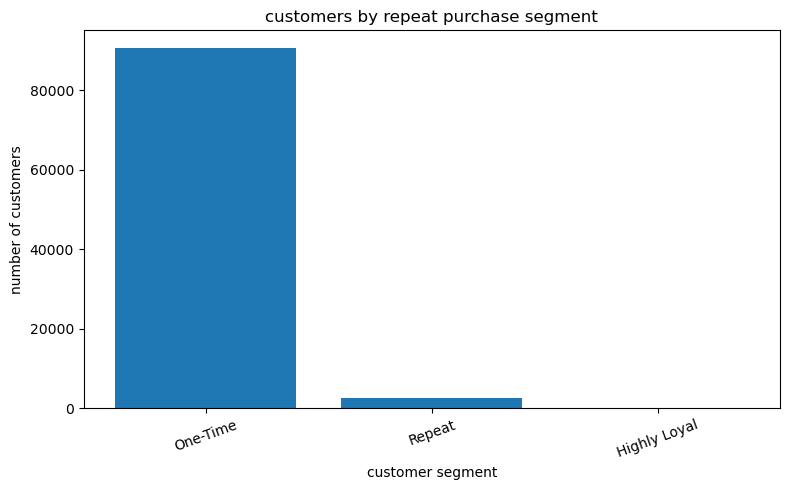

In [41]:
## customer segments
plt.figure(figsize=(8,5))
plt.bar(
    segment_summary["segment"].astype(str),
    segment_summary["customer"]
)
plt.title("customers by repeat purchase segment")
plt.xlabel("customer segment")
plt.ylabel("number of customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

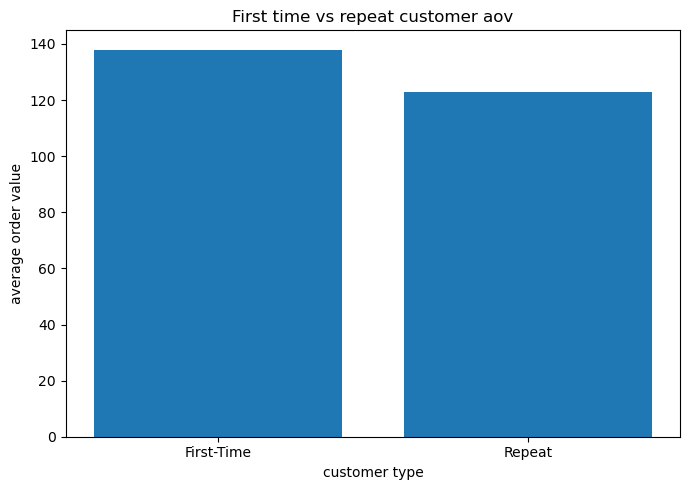

In [42]:
## first time vs repeat AOV
plt.figure(figsize=(7,5))
plt.bar(
    aov_summary["customer_type"],
    aov_summary["AOV"]
)
plt.title("First time vs repeat customer aov")
plt.xlabel("customer type")
plt.ylabel("average order value")
plt.tight_layout()
plt.show()

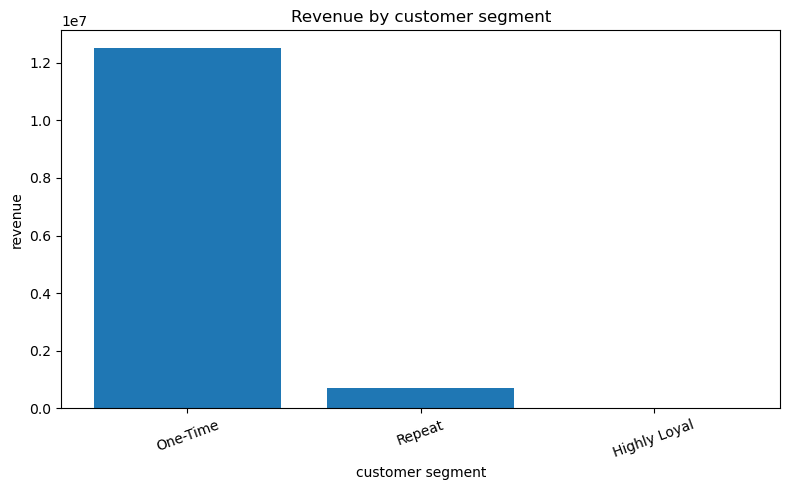

In [46]:
## revenue by segment
plt.figure(figsize=(8,5))
plt.bar(
    segment_summary["segment"].astype(str),
    segment_summary["revenue"]
)
plt.title("Revenue by customer segment")
plt.xlabel("customer segment")
plt.ylabel("revenue")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [48]:
## export results
customer_summary.to_csv(
    "customer_repeat_purchase_table.csv",
    index=False
)
segment_summary.to_csv(
    "repeat_customer_segment_table.csv",
    index=False
)
aov_summary.to_csv(
    "first_time_vs_repeat_aov.csv",
    index=False
)
repeat_rate_table.to_csv(
    "repeat_purchase_rate.csv",
    index=False
)
order_frequency.to_csv(
    "order_frequency.csv",
    index=False
)
print("\n All result tables exported sucessfull.")


 All result tables exported sucessfull.


In [50]:
print("KEY METRICS")
print(f"Repeat Purchase rate: {repeat_rate:.2f}%")
print(f"First-Time Customer AOV:"
      f"{aov_summary.loc[aov_summary['customer_type']=="First-Time",'AOV'].iloc[0]:.2f}")
print(f"Repeat Customer AOV:"

    f"{aov_summary.loc[aov_summary['customer_type']=='Repeat','AOV'].iloc[0]:.2f}")
largest_segment=segment_summary.loc[
    segment_summary["customer"].idxmax(),"segment"
]
highest_revenue_segment=segment_summary.loc[
    segment_summary["revenue"].idxmax(),"segment"
]
print("Largest Customer Segment:",largest_segment)
print("Highest Revenue Segment:",highest_revenue_segment)

KEY METRICS
Repeat Purchase rate: 3.00%
First-Time Customer AOV:137.96
Repeat Customer AOV:123.02
Largest Customer Segment: One-Time
Highest Revenue Segment: One-Time
